This notebook serves as a rough proof of concept where each step is executed manually, in order to test the technology before comitting it to a proper Python project structure.

Import the packages

In [ ]:
import cv2
import numpy as np
from IPython.display import display, clear_output
import IPython.display as ipd

Some sanity checks to ensure previous erroneous runs get cleaned up properly.

In [ ]:
try:
    
    camera.release()
    print("Cleaned up camera")
except NameError:
    print("No camera to clean up")
    pass

Open the camera

In [ ]:
camera = cv2.VideoCapture(0)

Configure stream

In [ ]:
frame_width = int(camera.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(camera.get(cv2.CAP_PROP_FRAME_HEIGHT))

Display stream in notebook

In [ ]:
if not camera.isOpened():
    print("Error: Could not open camera.")

try:
    while True:
        ret, frame = camera.read()
        if not ret:
            print("Error: Could not read frame.")
            break
        frame = cv2.resize(frame, (frame_width, frame_height))
        _, buffer = cv2.imencode('.jpg', frame)
        img_data = buffer.tobytes()
        clear_output(wait=True)
        display(ipd.Image(data=img_data))
except KeyboardInterrupt:
    pass
except Exception as e:
    print(f"An error occurred: {e}")    

Import hand classifier

This project uses a pretrained haar-type cascade classifier obtained [here](https://github.com/jac0x/webcam-hand-detect/blob/master/haarcascade_hand.xml). 

In [19]:
hand_cascade = cv2.CascadeClassifier('hand.xml')

Display stream in notebook, this time with bounding boxes.

Anything added in these steps is noted as such with a # NEW comment behind the line

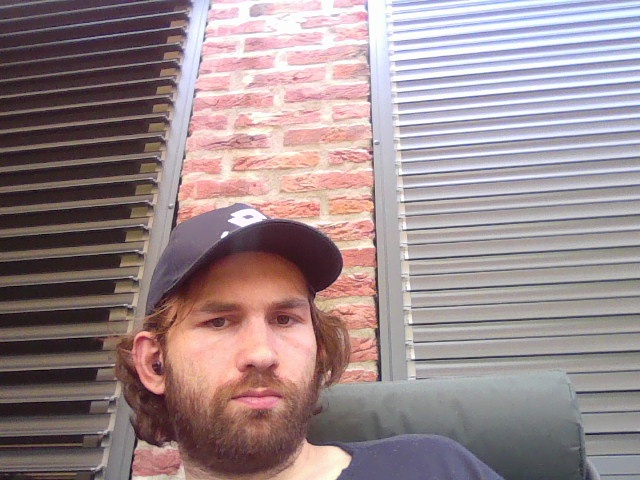

In [20]:
if not camera.isOpened():
    print("Error: Could not open camera.")

try:
    while True:
        ret, frame = camera.read()
        if not ret:
            print("Error: Could not read frame.")
            break
        frame = cv2.resize(frame, (frame_width, frame_height))
        
        bounding_boxes = hand_cascade.detectMultiScale(frame, scaleFactor=1.1, minNeighbors=5)
        overlays = []
        for (x, y, w, h) in bounding_boxes:
            overlay = frame.copy()
            cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)
            overlays.append(overlay)
        merged_frame = frame.copy()
        for overlay in overlays:
            merged_frame = cv2.addWeighted(merged_frame, 0.7, overlay, 0.3, 0)
        _, buffer = cv2.imencode('.jpg', merged_frame)
        img_data = buffer.tobytes()
        clear_output(wait=True)
        display(ipd.Image(data=img_data))
except KeyboardInterrupt:
    pass
except Exception as e:
    print(f"An error occurred: {e}")    